In [92]:
!pip install transformers torch

In [1]:
!pip install pandas_ta
!pip install yfinance

In [90]:
import yfinance as yf
import pandas as pd
import pandas_ta as ta
import numpy as np
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score
import matplotlib.pyplot as plt
import requests
from bs4 import BeautifulSoup
import spacy
from datasets import load_dataset
import re
import json

In [58]:
def get_dynamic_sp500_tickers():
    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/145.0.0.0 Safari/537.36"
    }
    response = requests.get(url, headers=headers)
    if response.status_code != 200:
        raise Exception(f"Failed to fetch Wikipedia page. Status code: {response.status_code}")
    soup = BeautifulSoup(response.text, 'html.parser')
    table = soup.find('table', {'id': 'constituents'})
    ticker_list = []
    for row in table.find_all('tr')[1:]:
        columns = row.find_all('td')
        if columns:
            ticker = columns[0].text.strip()
            ticker_clean = ticker.replace('.', '-')
            ticker_list.append(ticker_clean)
    return ticker_list

In [59]:
sp500_tickers = get_dynamic_sp500_tickers()

In [43]:
df_bulk = yf.download(tickers=sp500_tickers, start="1980-01-01", end="2023-12-31", group_by="ticker")

/tmp/ipykernel_973/3478295491.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_bulk = yf.download(tickers=sp500_tickers, start="1980-01-01", end="2023-12-31", group_by="ticker")
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[                       0%                       ]/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[                       0%                       ]  2 of 503 completed/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now

In [ ]:
from huggingface_hub import login
login(token="key")

In [91]:
print("Loading spaCy NLP model...")
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

# ==========================================
# 1. THE TEXT CLEANING PIPELINE
# ==========================================
def clean_financial_text(text):
    if not isinstance(text, str):
        return ""

    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'Click here for the latest stock market news.*', '', text, flags=re.IGNORECASE)

    doc = nlp(text)
    clean_tokens = [token.text for token in doc if not token.is_punct and not token.is_space]

    return " ".join(clean_tokens)

# ==========================================
# 2. STREAM THE HUGGING FACE DATASET (FIXED)
# ==========================================
print("Connecting to Hugging Face (Streaming Mode)...")

# FIX: We use data_dir to target the specific sub-folder of the dataset
dataset = load_dataset(
    "Brianferrell787/financial-news-multisource",
    data_dir="data/yahoo_finance_articles",
    split="train",
    streaming=True
)

print("Extracting the first 1,000 articles...")
articles = []
for i, row in enumerate(dataset):
    if i >= 1000:
        break
    articles.append(row)

df_news = pd.DataFrame(articles)

# ==========================================
# 3. UNPACK METADATA & APPLY THE CLEANER
# ==========================================
print("Unpacking metadata from 'extra_fields'...")

# Safely parse the raw string into a true Python dictionary
def parse_extra_fields(field):
    if isinstance(field, dict):
        return field
    try:
        return json.loads(field)
    except:
        return {} # Return empty dict if the row is corrupted/missing

# Apply the parser, then flatten the column
df_news['extra_fields'] = df_news['extra_fields'].apply(parse_extra_fields)
df_extras = pd.json_normalize(df_news['extra_fields'])

# Merge the new columns and drop the old combined one
df_news = pd.concat([df_news.drop(columns=['extra_fields']), df_extras], axis=1)

print("Applying spaCy text cleaner (This takes a few seconds)...")
df_news['clean_text'] = df_news['text'].apply(clean_financial_text)

print("\nPipeline Complete! Here is your clean data:")

# Safely pick columns to display
if 'title' in df_news.columns:
    display_cols = ['date_trading', 'title', 'clean_text']
elif 'headline' in df_news.columns:
    display_cols = ['date_trading', 'headline', 'clean_text']
else:
    display_cols = ['date_trading', 'clean_text']

print(df_news[display_cols].head())

Loading spaCy NLP model...
Connecting to Hugging Face (Streaming Mode)...
Extracting the first 1,000 articles...
Unpacking metadata from 'extra_fields'...
Applying spaCy text cleaner (This takes a few seconds)...

Pipeline Complete! Here is your clean data:
           date_trading                                         clean_text
0  2025-03-12T13:30:00Z  Ainos ASE to Use AI Nose Technology in Semicon...
1  2025-03-12T13:30:00Z  Why Argo Blockchain Plc ADR ARBK Is Plunging I...
2  2025-03-12T13:30:00Z  Achieve Life Sciences Reports Financial Result...
3  2025-03-12T13:30:00Z  Air Industries Group Secures Two Contracts wor...
4  2025-03-12T13:30:00Z  ALLETE Names Jeff Scissons Chief Financial Off...


In [93]:
from transformers import pipeline
import pandas as pd

print("Downloading and Loading FinBERT...")
# We use ProsusAI's FinBERT, which is specifically fine-tuned on financial text
sentiment_pipeline = pipeline("sentiment-analysis", model="ProsusAI/finbert")

# ==========================================
# 1. THE SENTIMENT SCORING LOGIC
# ==========================================
def get_finbert_sentiment(text):
    # Handle empty or missing text safely
    if not isinstance(text, str) or len(text.strip()) == 0:
        return 0.0

    try:
        # FinBERT has a 512 token limit. We truncate the text to prevent crashes on long articles.
        result = sentiment_pipeline(text, truncation=True, max_length=512)[0]

        label = result['label']
        score = result['score'] # The confidence probability (0.0 to 1.0)

        # Convert to a continuous numerical feature for XGBoost
        if label == 'positive':
            return score
        elif label == 'negative':
            return -score
        else:
            return 0.0 # Neutral

    except Exception as e:
        return 0.0

# ==========================================
# 2. APPLY TO OUR CLEAN DATA
# ==========================================
print("Extracting Sentiment Scores (This may take a minute on CPU)...")

# Apply the function to our clean_text column
df_news['finbert_score'] = df_news['clean_text'].apply(get_finbert_sentiment)

print("\nSentiment Extraction Complete!")
print(df_news[['date_trading', 'title', 'finbert_score']].head(10))

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Extracting Sentiment Scores (This may take a minute on CPU)...


KeyboardInterrupt: 

In [60]:
df_stacked = df_bulk.stack(level=0, future_stack=True).rename_axis(['Date', 'Ticker']).reset_index()
df_stacked = df_stacked.sort_values(by=['Date', 'Ticker'])
df_stacked.columns.name = None
df_stacked = df_stacked.set_index(['Date', 'Ticker'])

In [61]:
def calculate_features(group):
    # Group 1: pandas-ta features
    group.ta.rsi(length=14, append=True)
    group.ta.ppo(append=True)
    group.ta.obv(append=True)
    group.ta.atr(length=14, append=True)

    # Group 2: Custom Pandas Math
    group['Log_Return'] = np.log(group['Close'] / group['Close'].shift(1))
    group['Overnight_Gap'] = (group['Open'] - group['Close'].shift(1)) / group['Close'].shift(1)
    group['High_Low_Ratio'] = (group['High'] - group['Low']) / group['Close']

    return group

In [62]:
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
df_stacked[numeric_cols] = df_stacked[numeric_cols].apply(pd.to_numeric, errors='coerce')

In [63]:
if 'Adj Close' in df_stacked.columns:
    df_stacked = df_stacked.drop(columns=['Adj Close'])

# 2. Protect Date and Ticker in the index
if 'Ticker' in df_stacked.columns:
    df_stacked = df_stacked.set_index(['Date', 'Ticker'])
df_stacked = df_stacked.dropna()

In [64]:
df_stacked.head()

Open       High        Low      Close     Volume
Date       Ticker                                                       
1980-01-02 AEP      1.064612   1.072057   1.064612   1.064612    90000.0
           AIG     14.359092  14.359092  14.359092  14.359092        0.0
           APA      3.240803   3.240803   3.135124   3.135124    88358.0
           AVY      0.885894   0.892046   0.873590   0.873590   245600.0
           AXP      0.731408   0.737529   0.731408   0.731408  1755448.0

In [65]:
df_features = df_stacked.groupby(level='Ticker', group_keys=False).apply(calculate_features)
df_features = df_features.dropna().reset_index()

In [66]:
df_features.head()

,Date,Ticker,Open,High,Low,Close,Volume,RSI_14,PPO_12_26_9,PPOh_12_26_9,PPOs_12_26_9,OBV,ATRr_14,Log_Return,Overnight_Gap,High_Low_Ratio
0,1980-02-06,AEP,1.089637,1.097311,1.089637,1.089637,56100.0,57.366582,0.013359,0.0,0.013359,134900.0,0.015373,0.000000,0.000000e+00,0.007042
1,1980-02-06,AIG,14.359092,14.359092,14.359092,14.359092,0.0,41.639635,-0.457310,0.0,-0.457310,0.0,0.146027,0.008658,8.695904e-03,0.000000
2,1980-02-06,APA,3.369965,3.722226,3.369965,3.710484,188150.0,73.488155,2.436359,0.0,2.436359,-78482.0,0.127215,0.096260,4.042548e-07,0.094937
3,1980-02-06,AVY,1.082759,1.138127,1.082759,1.119671,304800.0,63.630023,6.349999,0.0,6.349999,3121600.0,0.032932,0.033522,-4.621684e-07,0.049451
4,1980-02-06,AXP,0.713046,0.713046,0.688564,0.703865,3304282.0,29.571537,-1.623971,0.0,-1.623971,-19699858.0,0.019037,-0.029981,-1.687742e-02,0.034783


In [67]:
# Restore the correct 5 macroeconomic benchmarks
benchmark_tickers = ['^TNX', '^IRX', '^VIX', 'DX-Y.NYB', 'XLK']

print("Downloading Macroeconomic Benchmarks...")
df_bench = yf.download(benchmark_tickers, start="1980-01-01", end="2023-12-31")['Close']

# Calculate Macro Features
df_macro = pd.DataFrame(index=df_bench.index)
df_macro['Term_Spread'] = df_bench['^TNX'] - df_bench['^IRX']
df_macro['VIX'] = df_bench['^VIX']
df_macro['USD_Index'] = df_bench['DX-Y.NYB']
df_macro['XLK_Log_Return'] = np.log(df_bench['XLK'] / df_bench['XLK'].shift(1))
df_macro = df_macro.dropna().reset_index()

# ==========================================
# 1. THE TUPLE CRUSHER (Flatten all columns)
# ==========================================
df_features.columns = [col[0] if isinstance(col, tuple) else col for col in df_features.columns]
df_macro.columns = [col[0] if isinstance(col, tuple) else col for col in df_macro.columns]

if isinstance(df_features.columns, pd.MultiIndex):
    df_features.columns = df_features.columns.get_level_values(0)

# ==========================================
# 2. THE DATE COLUMN FIX
# ==========================================
# Fix df_macro's Date Column
if 'Date' not in df_macro.columns:
    df_macro = df_macro.rename(columns={df_macro.columns[0]: 'Date'})

# Fix df_features' Date Column
if 'Ticker' not in df_features.columns:
    df_features = df_features.reset_index()
if 'Date' not in df_features.columns:
    df_features = df_features.rename(columns={df_features.columns[0]: 'Date'})

# Standardize Datetimes
df_features['Date'] = pd.to_datetime(df_features['Date']).dt.tz_localize(None)
df_macro['Date'] = pd.to_datetime(df_macro['Date']).dt.tz_localize(None)

# ==========================================
# 3. MERGING
# ==========================================
print("Merging Macro features into the main dataset...")
df_final = pd.merge(df_features, df_macro, on='Date', how='left')

df_final['Sector_Relative_Strength'] = df_final['Log_Return'] - df_final['XLK_Log_Return']
df_final = df_final.drop(columns=['XLK_Log_Return'])
df_final = df_final.sort_values(by=['Date', 'Ticker'])

print("\nSuccessfully Merged Data:")
print(df_final.head(5))

/tmp/ipykernel_973/3818644334.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_bench = yf.download(benchmark_tickers, start="1980-01-01", end="2023-12-31")['Close']
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[                       0%                       ]

/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*******************   40%                       ]  2 of 5 completed/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  5 of 5 completed


Merging Macro features into the main dataset...

Successfully Merged Data:
        Date Ticker       Open       High        Low      Close     Volume  \
0 1980-02-06    AEP   1.089637   1.097311   1.089637   1.089637    56100.0   
1 1980-02-06    AIG  14.359092  14.359092  14.359092  14.359092        0.0   
2 1980-02-06    APA   3.369965   3.722226   3.369965   3.710484   188150.0   
3 1980-02-06    AVY   1.082759   1.138127   1.082759   1.119671   304800.0   
4 1980-02-06    AXP   0.713046   0.713046   0.688564   0.703865  3304282.0   

      RSI_14  PPO_12_26_9  PPOh_12_26_9  PPOs_12_26_9         OBV   ATRr_14  \
0  57.366582     0.013359           0.0      0.013359    134900.0  0.015373   
1  41.639635    -0.457310           0.0     -0.457310         0.0  0.146027   
2  73.488155     2.436359           0.0      2.436359    -78482.0  0.127215   
3  63.630023     6.349999           0.0      6.349999   3121600.0  0.032932   
4  29.571537    -1.623971           0.0     -1.623971 -196998

# First Model

In [79]:
features = [
    'RSI_14', 'PPO_12_26_9', 'PPOh_12_26_9', 'PPOs_12_26_9', 'OBV', 'ATRr_14',
    'Log_Return', 'Overnight_Gap', 'High_Low_Ratio', 'Term_Spread', 'VIX',
    'USD_Index', 'Sector_Relative_Strength'
]

# ==========================================
# 1. NEW TARGET: FIXING EXECUTION BIAS
# ==========================================
df_final = df_final.sort_values(by=['Date', 'Ticker'])

# We keep Next_Day_Return for the AI to learn general momentum
df_final['Next_Close'] = df_final.groupby('Ticker')['Close'].shift(-1)
df_final['Next_Day_Return'] = (df_final['Next_Close'] - df_final['Close']) / df_final['Close']

# REALITY CHECK: We evaluate using Actionable_Return (Tomorrow's Open to Tomorrow's Close)
df_final['Next_Open'] = df_final.groupby('Ticker')['Open'].shift(-1)
df_final['Actionable_Return'] = (df_final['Next_Close'] - df_final['Next_Open']) / df_final['Next_Open']

df_final = df_final.dropna()

# If tomorrow's return is greater than 0, target is 1. Otherwise, 0.
df_final['Target_Direction'] = (df_final['Next_Day_Return'] > 0).astype(int)

# ==========================================
# 2. PERFORM THE TIME-SERIES SPLIT
# ==========================================
split_date = '2010-01-01'
train_data = df_final[df_final['Date'] < split_date]
test_data  = df_final[df_final['Date'] >= split_date]

X_train = train_data[features]
y_train = train_data['Target_Direction']

X_test = test_data[features]
y_test = test_data['Next_Day_Return']

# ==========================================
# 3. TRAIN THE CLASSIFIER
# ==========================================
classifier = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.5,
    colsample_bytree=0.5,
    random_state=42
)

print("Training XGBClassifier on Binary Targets...")
classifier.fit(X_train, y_train)

# ==========================================
# 4. PREDICT PROBABILITIES
# ==========================================
test_data_eval = test_data.copy()
test_data_eval['Predicted_Probability'] = classifier.predict_proba(X_test)[:, 1]

print("Training & Predictions Complete!")

Training XGBClassifier on Binary Targets...
Training & Predictions Complete!


<Figure size 1000x600 with 0 Axes>

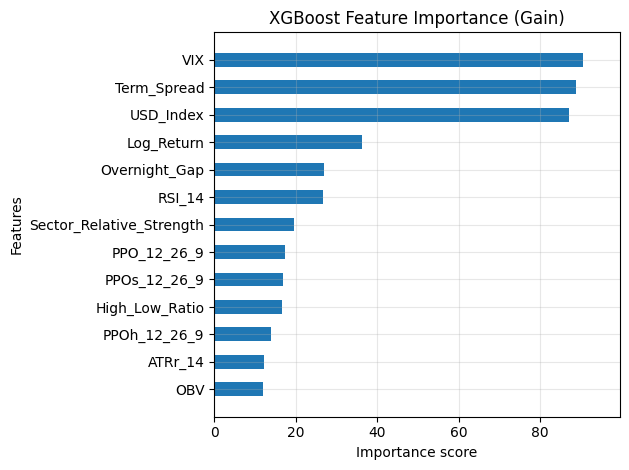


Exact Feature Importance Rankings:
                     Feature  Importance_Score
0                        VIX          0.194691
1                Term_Spread          0.191188
2                  USD_Index          0.187457
3                 Log_Return          0.077988
4              Overnight_Gap          0.058214
5                     RSI_14          0.057389
6   Sector_Relative_Strength          0.041871
7                PPO_12_26_9          0.037646
8               PPOs_12_26_9          0.036146
9             High_Low_Ratio          0.035597
10              PPOh_12_26_9          0.030026
11                   ATRr_14          0.026210
12                       OBV          0.025576


In [80]:
# ==========================================
# 1. VISUALIZE FEATURE IMPORTANCE
# ==========================================
plt.figure(figsize=(10, 6))

# We use importance_type='gain' because it measures the actual improvement in accuracy a feature brings
xgb.plot_importance(classifier, importance_type='gain', max_num_features=15, height=0.5, show_values=False)
plt.title('XGBoost Feature Importance (Gain)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ==========================================
# 2. CREATE A CLEAN DATAFRAME
# ==========================================
# Extract the raw importance percentages
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance_Score': classifier.feature_importances_
})

# Sort them from most important to least important
importance_df = importance_df.sort_values(by='Importance_Score', ascending=False).reset_index(drop=True)

print("\nExact Feature Importance Rankings:")
print(importance_df)

In [82]:
# ==========================================
# 1. SET PARAMETERS & FRICTION
# ==========================================
BEST_BUY = 0.50
BEST_SELL = 0.40
MAX_POSITIONS = 25
TRANSACTION_COST = 0.001  # 0.10% slippage/commission per trade

dates = sorted(test_data_eval['Date'].unique())
portfolio_weights = {}
cash_weight = 1.0

daily_returns_list = []
market_returns_list = []

print(f"Running Institutional Backtest (With Trading Fees)...")

# ==========================================
# 2. RUN THE FASTER GROUPBY BACKTEST
# ==========================================
# This is much faster than boolean masking every day
grouped_data = test_data_eval.groupby('Date')

for i, date in enumerate(dates):
    # Safely get the data for this date, or an empty dataframe if missing
    day_data = grouped_data.get_group(date) if date in grouped_data.groups else pd.DataFrame()

    if day_data.empty:
        daily_returns_list.append(0.0)
        market_returns_list.append(0.0)
        continue

    prob_dict = dict(zip(day_data['Ticker'], day_data['Predicted_Probability']))
    ret_dict = dict(zip(day_data['Ticker'], day_data['Actionable_Return']))

    daily_fees = 0.0 # Track fees paid today

    # --- 1. SELL LOGIC ---
    tickers_to_remove = []
    for ticker in portfolio_weights.keys():
        if ticker not in prob_dict or prob_dict[ticker] < BEST_SELL:
            tickers_to_remove.append(ticker)

    for ticker in tickers_to_remove:
        # Deduct transaction cost from the cashed-out weight
        cash_weight += portfolio_weights[ticker] * (1 - TRANSACTION_COST)
        daily_fees += portfolio_weights[ticker] * TRANSACTION_COST
        del portfolio_weights[ticker]

    # --- 2. BUY LOGIC ---
    open_slots = MAX_POSITIONS - len(portfolio_weights)
    if open_slots > 0:
        candidates = day_data[
            (day_data['Predicted_Probability'] > BEST_BUY) &
            (~day_data['Ticker'].isin(portfolio_weights.keys()))
        ]
        candidates = candidates.sort_values(by='Predicted_Probability', ascending=False)
        top_candidates = candidates.head(open_slots)['Ticker'].tolist()

        for ticker in top_candidates:
            target_weight = 1.0 / MAX_POSITIONS
            actual_buy_weight = min(target_weight, cash_weight)

            if actual_buy_weight > 0:
                # Deduct transaction cost before the stock enters the portfolio
                portfolio_weights[ticker] = actual_buy_weight * (1 - TRANSACTION_COST)
                cash_weight -= actual_buy_weight
                daily_fees += actual_buy_weight * TRANSACTION_COST

    # --- 3. CALCULATE PORTFOLIO RETURN ---
    daily_portfolio_return = 0.0

    for ticker, weight in portfolio_weights.items():
        stock_return = ret_dict.get(ticker, 0.0)
        daily_portfolio_return += weight * stock_return

    # Subtract the sheer drag of today's trading fees from the daily return
    daily_portfolio_return -= daily_fees

    daily_returns_list.append(daily_portfolio_return)
    market_returns_list.append(day_data['Actionable_Return'].mean())

    # --- 4. DRIFT THE WEIGHTS ---
    portfolio_growth = 1.0 + daily_portfolio_return
    for ticker in portfolio_weights.keys():
        stock_return = ret_dict.get(ticker, 0.0)
        portfolio_weights[ticker] = (portfolio_weights[ticker] * (1.0 + stock_return)) / portfolio_growth
    cash_weight = cash_weight / portfolio_growth

    # --- 5. ROBUST QUARTERLY REBALANCING ---
    is_quarter_start = date.is_quarter_start if hasattr(date, 'is_quarter_start') else False

    if is_quarter_start:
        total_portfolio_value = cash_weight + sum(portfolio_weights.values())
        held_count = len(portfolio_weights)

        if held_count > 0:
            rebalanced_weight = (total_portfolio_value - cash_weight) / held_count
            for ticker in portfolio_weights.keys():
                portfolio_weights[ticker] = rebalanced_weight

# ==========================================
# 3. RISK METRICS & AGGREGATION
# ==========================================
df_returns = pd.DataFrame({
    'Date': dates,
    'AI_Strategy': daily_returns_list,
    'Market_Baseline': market_returns_list
})
df_returns['Date'] = pd.to_datetime(df_returns['Date'])
df_returns.set_index('Date', inplace=True)

def compound_return(series):
    return (np.prod(1 + series) - 1) * 100

total_ai = compound_return(df_returns['AI_Strategy'])
total_market = compound_return(df_returns['Market_Baseline'])

# Calculate Sharpe Ratio (Assuming Risk-Free Rate is 0 for simplicity)
ai_sharpe = (df_returns['AI_Strategy'].mean() / df_returns['AI_Strategy'].std()) * np.sqrt(252)
market_sharpe = (df_returns['Market_Baseline'].mean() / df_returns['Market_Baseline'].std()) * np.sqrt(252)

# Calculate Maximum Drawdown
def max_drawdown(return_series):
    compounded_index = (1 + return_series).cumprod()
    peak = compounded_index.cummax()
    drawdown = (compounded_index - peak) / peak
    return drawdown.min() * 100

ai_mdd = max_drawdown(df_returns['AI_Strategy'])
market_mdd = max_drawdown(df_returns['Market_Baseline'])

print("\n" + "="*55)
print("🏆 FINAL STRATEGY TEAR SHEET 🏆")
print("="*55)
print(f"Total Return:      AI = {total_ai:>8.2f}%  |  MARKET = {total_market:>8.2f}%")
print(f"Sharpe Ratio:      AI = {ai_sharpe:>8.2f}   |  MARKET = {market_sharpe:>8.2f}")
print(f"Max Drawdown:      AI = {ai_mdd:>8.2f}%  |  MARKET = {market_mdd:>8.2f}%")
print("="*55)

Running Institutional Backtest (With Trading Fees)...

🏆 FINAL STRATEGY TEAR SHEET 🏆
Total Return:      AI =   320.86%  |  MARKET =   194.55%
Sharpe Ratio:      AI =     0.87   |  MARKET =     0.64
Max Drawdown:      AI =   -17.69%  |  MARKET =   -20.60%
